# Stochastic solving

First we set up an SIR model with pygom.
The stochastic solver is not yet integrated into pygom class so we extract the necessary attributes and feed them in to the solver.

In [ ]:
from pygom import SquareLoss, NormalLoss
from pygom.model import common_models
from pygom import approximate_bayesian_computation as pgabc

import numpy as np

import matplotlib.pyplot as plt

# define the model and parameters
beta = 0.5
gamma = 0.33
model = common_models.SIR_norm({'beta':beta, 'gamma':gamma})

i0=1e-4
x0 = [1-i0, i0, 0]
t = np.linspace(0, 150, 100)
model.initial_values = (x0, t[0])

sol = model.solve_deterministic(t).result.y
# print(sol)

y = sol[1:, 1]
theta = np.array([beta, gamma])
sql = NormalLoss(theta, model, x0, t[0], t[1::], y, ['I'], sigma=1.0)

In [15]:
y

array([1.30225296e-04, 1.68529075e-04, 2.18021763e-04, 2.81951868e-04,
       3.64734083e-04, 4.71645978e-04, 6.09799379e-04, 7.88165034e-04,
       1.01782833e-03, 1.31346560e-03, 1.69375592e-03, 2.18227010e-03,
       2.80841581e-03, 3.60814920e-03, 4.62610173e-03, 5.91529602e-03,
       7.53847528e-03, 9.56572170e-03, 1.20734457e-02, 1.51351462e-02,
       1.88177490e-02, 2.31554904e-02, 2.81484552e-02, 3.37145342e-02,
       3.97014414e-02, 4.58430426e-02, 5.17907340e-02, 5.71386193e-02,
       6.14650132e-02, 6.44259050e-02, 6.57922983e-02, 6.55021837e-02,
       6.36560876e-02, 6.05011092e-02, 5.63448384e-02, 5.15435725e-02,
       4.64042271e-02, 4.12319187e-02, 3.62091344e-02, 3.14907087e-02,
       2.71582405e-02, 2.32522452e-02, 1.97900216e-02, 1.67543111e-02,
       1.41259829e-02, 1.18651379e-02, 9.93770670e-03, 8.30349725e-03,
       6.92431581e-03, 5.76437896e-03, 4.79197820e-03, 3.97896595e-03,
       3.30087265e-03, 2.73622053e-03, 2.26668874e-03, 1.87652178e-03,
      

In [16]:
y2 = sql._ode.integrate(sql._observeT)

y2

array([[9.99900000e-01, 1.00000000e-04, 0.00000000e+00],
       [9.99813581e-01, 1.29374318e-04, 5.70448111e-05],
       [9.99701831e-01, 1.67351251e-04, 1.30817356e-04],
       [9.99557279e-01, 2.16463823e-04, 2.26257645e-04],
       [9.99370376e-01, 2.79944575e-04, 3.49679668e-04],
       [9.99128726e-01, 3.61985811e-04, 5.09288632e-04],
       [9.98816370e-01, 4.67974682e-04, 7.15655645e-04],
       [9.98412759e-01, 6.04832564e-04, 9.82408321e-04],
       [9.97891453e-01, 7.81439528e-04, 1.32710764e-03],
       [9.97218497e-01, 1.00915580e-03, 1.77234748e-03],
       [9.96350343e-01, 1.30247922e-03, 2.34717802e-03],
       [9.95231388e-01, 1.67980142e-03, 3.08881080e-03],
       [9.93790830e-01, 2.16434222e-03, 4.04482806e-03],
       [9.91938965e-01, 2.78519047e-03, 5.27584493e-03],
       [9.89562860e-01, 3.57842193e-03, 6.85871849e-03],
       [9.86521494e-01, 4.58818598e-03, 8.89032026e-03],
       [9.82640652e-01, 5.86754889e-03, 1.14917987e-02],
       [9.77708122e-01, 7.47874

In [17]:
yhat = sql._getSolution(theta)

yhat

array([[1.30225296e-04],
       [1.68529075e-04],
       [2.18021763e-04],
       [2.81951868e-04],
       [3.64734083e-04],
       [4.71645978e-04],
       [6.09799379e-04],
       [7.88165034e-04],
       [1.01782833e-03],
       [1.31346560e-03],
       [1.69375592e-03],
       [2.18227010e-03],
       [2.80841581e-03],
       [3.60814920e-03],
       [4.62610173e-03],
       [5.91529602e-03],
       [7.53847528e-03],
       [9.56572170e-03],
       [1.20734457e-02],
       [1.51351462e-02],
       [1.88177490e-02],
       [2.31554904e-02],
       [2.81484552e-02],
       [3.37145342e-02],
       [3.97014414e-02],
       [4.58430426e-02],
       [5.17907340e-02],
       [5.71386193e-02],
       [6.14650132e-02],
       [6.44259050e-02],
       [6.57922983e-02],
       [6.55021837e-02],
       [6.36560876e-02],
       [6.05011092e-02],
       [5.63448384e-02],
       [5.15435725e-02],
       [4.64042271e-02],
       [4.12319187e-02],
       [3.62091344e-02],
       [3.14907087e-02],


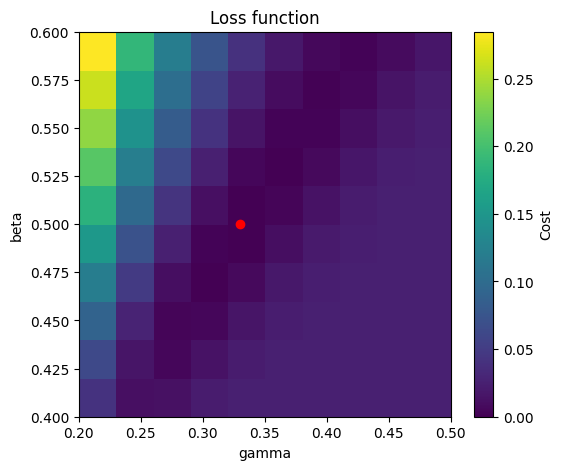

In [8]:
N = 10
cost = np.zeros( (N, N) )
# betas = np.linspace(0.45, 0.55, N)
# gammas = np.linspace(0.30, 0.36, N)

betas = np.linspace(0.4, 0.6, N)
gammas = np.linspace(0.2, 0.5, N)


for i in range(N):
    for j in range(N):
        theta = np.array([betas[i], gammas[j]])
        cost[i][j] = sql.cost(theta)

cost = cost - cost.min()

plt.figure(figsize=(6, 5))
plt.imshow(cost, extent=[gammas.min(), gammas.max(), betas.min(), betas.max()],
           origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label="Cost")
plt.xlabel("gamma")
plt.ylabel("beta")
plt.title("Loss function")
plt.scatter(x=gamma, y=beta, color="red")
plt.show()


array([0.50376484, 0.33669519])

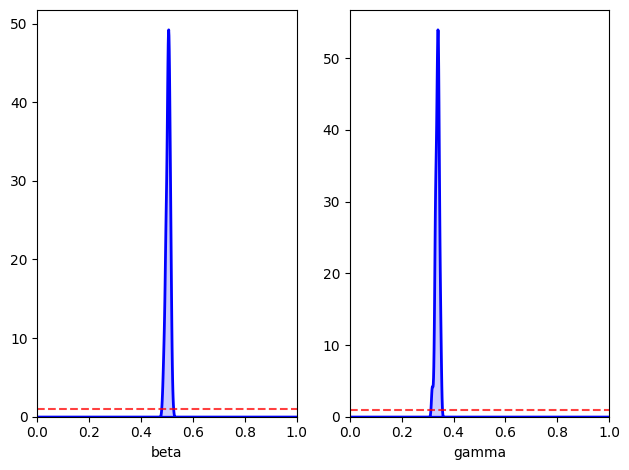

In [11]:
# setting the parameters in the inference
parameters = [pgabc.Parameter('beta', 'unif', 0, 1.0, logscale=False),
              pgabc.Parameter('gamma', 'unif', 0, 1.0, logscale=False)]

# creating the loss and abc objects
# sir_obj = pgabc.create_loss("SquareLoss", parameters, model, x0, t[0],
#                             t[1::], y, ['I'])

sir_obj = pgabc.create_loss("NormalLoss", parameters, model, x0, t[0],
                            t[1::], y, ['I'], sigma=1.0)

sir_abc = pgabc.ABC(sir_obj, parameters)

# getting the posterior sample
sir_abc.get_posterior_sample(N=100, tol=np.inf, G=10, q=0.5)
out = sir_abc.plot_posterior_histograms()
np.median(sir_abc.res, axis=0)